In [1]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
load_dotenv()
from lib.bck002 import rebuild_executed_signal_for_eval
from lib.cux001 import FactorEvaluate1

In [2]:
period = 5
ret_col = f"nxt1_ret_{period}h"

In [3]:
signal_path = "/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/signal/rl/1018806311332385/erband_signal/1002_test.feather"

position_path ='/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/backtest/rl/1013836755991964/1018806311332385/erband_signal/1002_test/position_data.feather'

trader_path ='/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/backtest/rl/1013836755991964/1018806311332385/erband_signal/1002_test/trade_records.feather'

In [4]:
signal_data = pd.read_feather(signal_path)
position_data = pd.read_feather(position_path)
trader_data = pd.read_feather(trader_path)#.drop_duplicates(subset=['date','min_time','code','direction','signal_type'])

In [5]:
#trader_data[trader_data.duplicated(subset=['date','min_time','code','direction','signal_type'])].head()

In [7]:
executed_signal = rebuild_executed_signal_for_eval(
    signal_data=signal_data,
    position_data=position_data,  # 原始完整 position_data，不要提前过滤列
    signal_col="signal",
)

In [8]:
trader_data['trade_time'] = pd.to_datetime(
    trader_data['date'].astype(str) +
    trader_data['min_time'].astype(str).str.zfill(4),
    format='%Y-%m-%d%H%M')

In [9]:
trader_data.set_index('trade_time').loc['2024-04-18 21:09:00']

,date,min_time,code,direction,numbers,theoretical_price,exec_price,close_price,multiplier,pnl,signal_type
trade_time,,,,,,,,,,,
2024-04-18 21:09:00,2024-04-18,2109,RB,-1,1,3685.962154,3685.962154,3681.952381,10,40.097729,regular
2024-04-18 21:09:00,2024-04-18,2109,RB,-1,1,3685.962154,3685.962154,3681.952381,10,40.097729,regular


In [7]:
signal_data.tail()

,trade_time,code,signal,symbol,task_id,value,confidence,net_er_out,er_value,nxt1_ret_5h
169613,2026-04-29 22:57:00,RB,0,rbb9999,113001,"[-0.40899789333343506, 0.43656063079833984, 0....",0.270531,0.270531,0.270531,0.000698
169614,2026-04-29 22:58:00,RB,0,rbb9999,113001,"[-0.7708642482757568, -0.030861496925354004, -...",0.200000,0.200000,0.200000,0.000673
169615,2026-04-29 22:59:00,RB,-1,rbb9999,113001,"[0.22344326972961426, -0.4226309061050415, 0.6...",0.801181,-0.801181,-0.801181,0.000891
169616,2026-04-29 23:00:00,RB,-1,rbb9999,113001,"[0.7413473129272461, -0.9282691478729248, 0.97...",0.716914,-0.716914,-0.716914,0.000425
169617,2026-04-30 09:00:00,RB,-1,rbb9999,113001,"[-0.9233148694038391, -0.9062903523445129, -0....",0.666078,-0.666078,-0.666078,0.000241


In [8]:
position_data.head()

,date,min_time,code,direction,numbers,pair_id,source_value,open_trade_time,close_trade_time,trade_time,signal_type
0,2024-04-18,2104,RB,1,1,1,0.881753,2024-04-18 21:04:00,2024-04-18 21:09:00,2024-04-18 21:04:00,open
1,2024-04-18,2105,RB,1,1,2,0.723062,2024-04-18 21:05:00,2024-04-18 21:10:00,2024-04-18 21:05:00,open
2,2024-04-18,2106,RB,1,1,3,0.735966,2024-04-18 21:06:00,2024-04-18 21:11:00,2024-04-18 21:06:00,open
3,2024-04-18,2107,RB,1,1,4,0.958070,2024-04-18 21:07:00,2024-04-18 21:12:00,2024-04-18 21:07:00,open
4,2024-04-18,2109,RB,-1,1,1,0.881753,2024-04-18 21:04:00,2024-04-18 21:09:00,2024-04-18 21:09:00,close


In [9]:
trader_data.head()

,date,min_time,code,direction,numbers,theoretical_price,exec_price,close_price,multiplier,pnl,signal_type,trade_time
0,2024-04-18,2100,RB,0,10,3688.637738,3688.637738,3681.952381,10,0.000000,base_position,2024-04-18 21:00:00
1,2024-04-18,2104,RB,1,1,3678.835777,3678.835777,3681.952381,10,31.166044,regular,2024-04-18 21:04:00
2,2024-04-18,2105,RB,1,1,3678.895963,3678.895963,3681.952381,10,30.564182,regular,2024-04-18 21:05:00
3,2024-04-18,2106,RB,1,1,3679.710062,3679.710062,3681.952381,10,22.423192,regular,2024-04-18 21:06:00
4,2024-04-18,2107,RB,1,1,3682.875253,3682.875253,3681.952381,10,-9.228723,regular,2024-04-18 21:07:00


In [10]:
executed_signal.head()

,trade_time,code,signal,symbol,task_id,value,confidence,net_er_out,er_value,nxt1_ret_5h,raw_signal,executed_signal,executed_lots,is_executable
0,2024-04-18 21:04:00,RB,1,rbb9999,113001,"[-0.9177427291870117, 0.2626307010650635, -0.4...",0.881753,0.881753,0.881753,0.000946,1,1,1,True
1,2024-04-18 21:05:00,RB,1,rbb9999,113001,"[-0.7601301670074463, 0.7531843185424805, 0.29...",0.723062,0.723062,0.723062,0.000422,1,1,1,True
2,2024-04-18 21:06:00,RB,1,rbb9999,113001,"[-0.21360868215560913, 0.16371333599090576, -0...",0.735966,0.735966,0.735966,0.000629,1,1,1,True
3,2024-04-18 21:07:00,RB,1,rbb9999,113001,"[-0.7692319750785828, 0.7072559595108032, -0.2...",0.958070,0.958070,0.958070,0.000352,1,1,1,True
4,2024-04-18 21:08:00,RB,0,rbb9999,113001,"[-0.6830067038536072, -0.211450457572937, -0.1...",0.197368,-0.197368,-0.197368,0.000031,0,0,0,False


#### 目标仓位数据和原始信号数据是否一致--开仓信号

In [11]:
position_open = position_data[position_data['signal_type'] == 'open'].copy()
position_check = position_open[[
    'trade_time', 'code', 'direction', 'numbers', 'pair_id'
]].merge(signal_data[['trade_time', 'code', 'signal', 'nxt1_ret_5h']],
         on=['trade_time', 'code'],
         how='left')

print("position open vs raw signal diff:")
print((position_check['direction'] != position_check['signal']).mean())
print(pd.crosstab(position_check['direction'], position_check['signal']))


position open vs raw signal diff:
0.0
signal        -1      1
direction              
-1         51784      0
 1             0  83206


#### 目标仓位数据和成交数据是否一致--开平信号

In [12]:
trader_regular = trader_data[trader_data['signal_type'] == 'regular'].copy()
trade_check = trader_regular[[
    'trade_time', 'code', 'direction', 'numbers', 'exec_price', 'pnl',
    'signal_type'
]].merge(position_data[[
    'trade_time', 'code', 'direction', 'numbers', 'signal_type'
]],
         on=['trade_time', 'code', 'direction', 'numbers'],
         how='left',
         suffixes=('_trade', '_position'))
print("trade records missing position rows:")
print(trade_check['signal_type_position'].isna().mean())
print(trade_check[trade_check['signal_type_position'].isna()].head(20))

trade records missing position rows:
0.0
Empty DataFrame
Columns: [trade_time, code, direction, numbers, exec_price, pnl, signal_type_trade, signal_type_position]
Index: []


### 原始信号和成交数据是否一致 -- 开仓记录

In [13]:
open_trade = trade_check[trade_check['signal_type_position'] == 'open'].copy()
open_cmp = open_trade.merge(
    signal_data[["trade_time", "code", "signal", "nxt1_ret_5h"]],
    on=["trade_time", "code"],
    how="left"
)
bad_open = open_cmp[
    open_cmp["direction"] != open_cmp["signal"]
]
print("open diff ratio:")
print(len(bad_open) / len(open_cmp))
print(pd.crosstab(open_cmp["direction"], open_cmp["signal"]))

open diff ratio:
0.0
signal        -1      1
direction              
-1         67997      0
 1             0  97456


In [14]:
position_check.head()

,trade_time,code,direction,numbers,pair_id,signal,nxt1_ret_5h
0,2024-04-18 21:04:00,RB,1,1,1,1,0.000946
1,2024-04-18 21:05:00,RB,1,1,2,1,0.000422
2,2024-04-18 21:06:00,RB,1,1,3,1,0.000629
3,2024-04-18 21:07:00,RB,1,1,4,1,0.000352
4,2024-04-18 21:09:00,RB,-1,1,5,-1,-0.000164


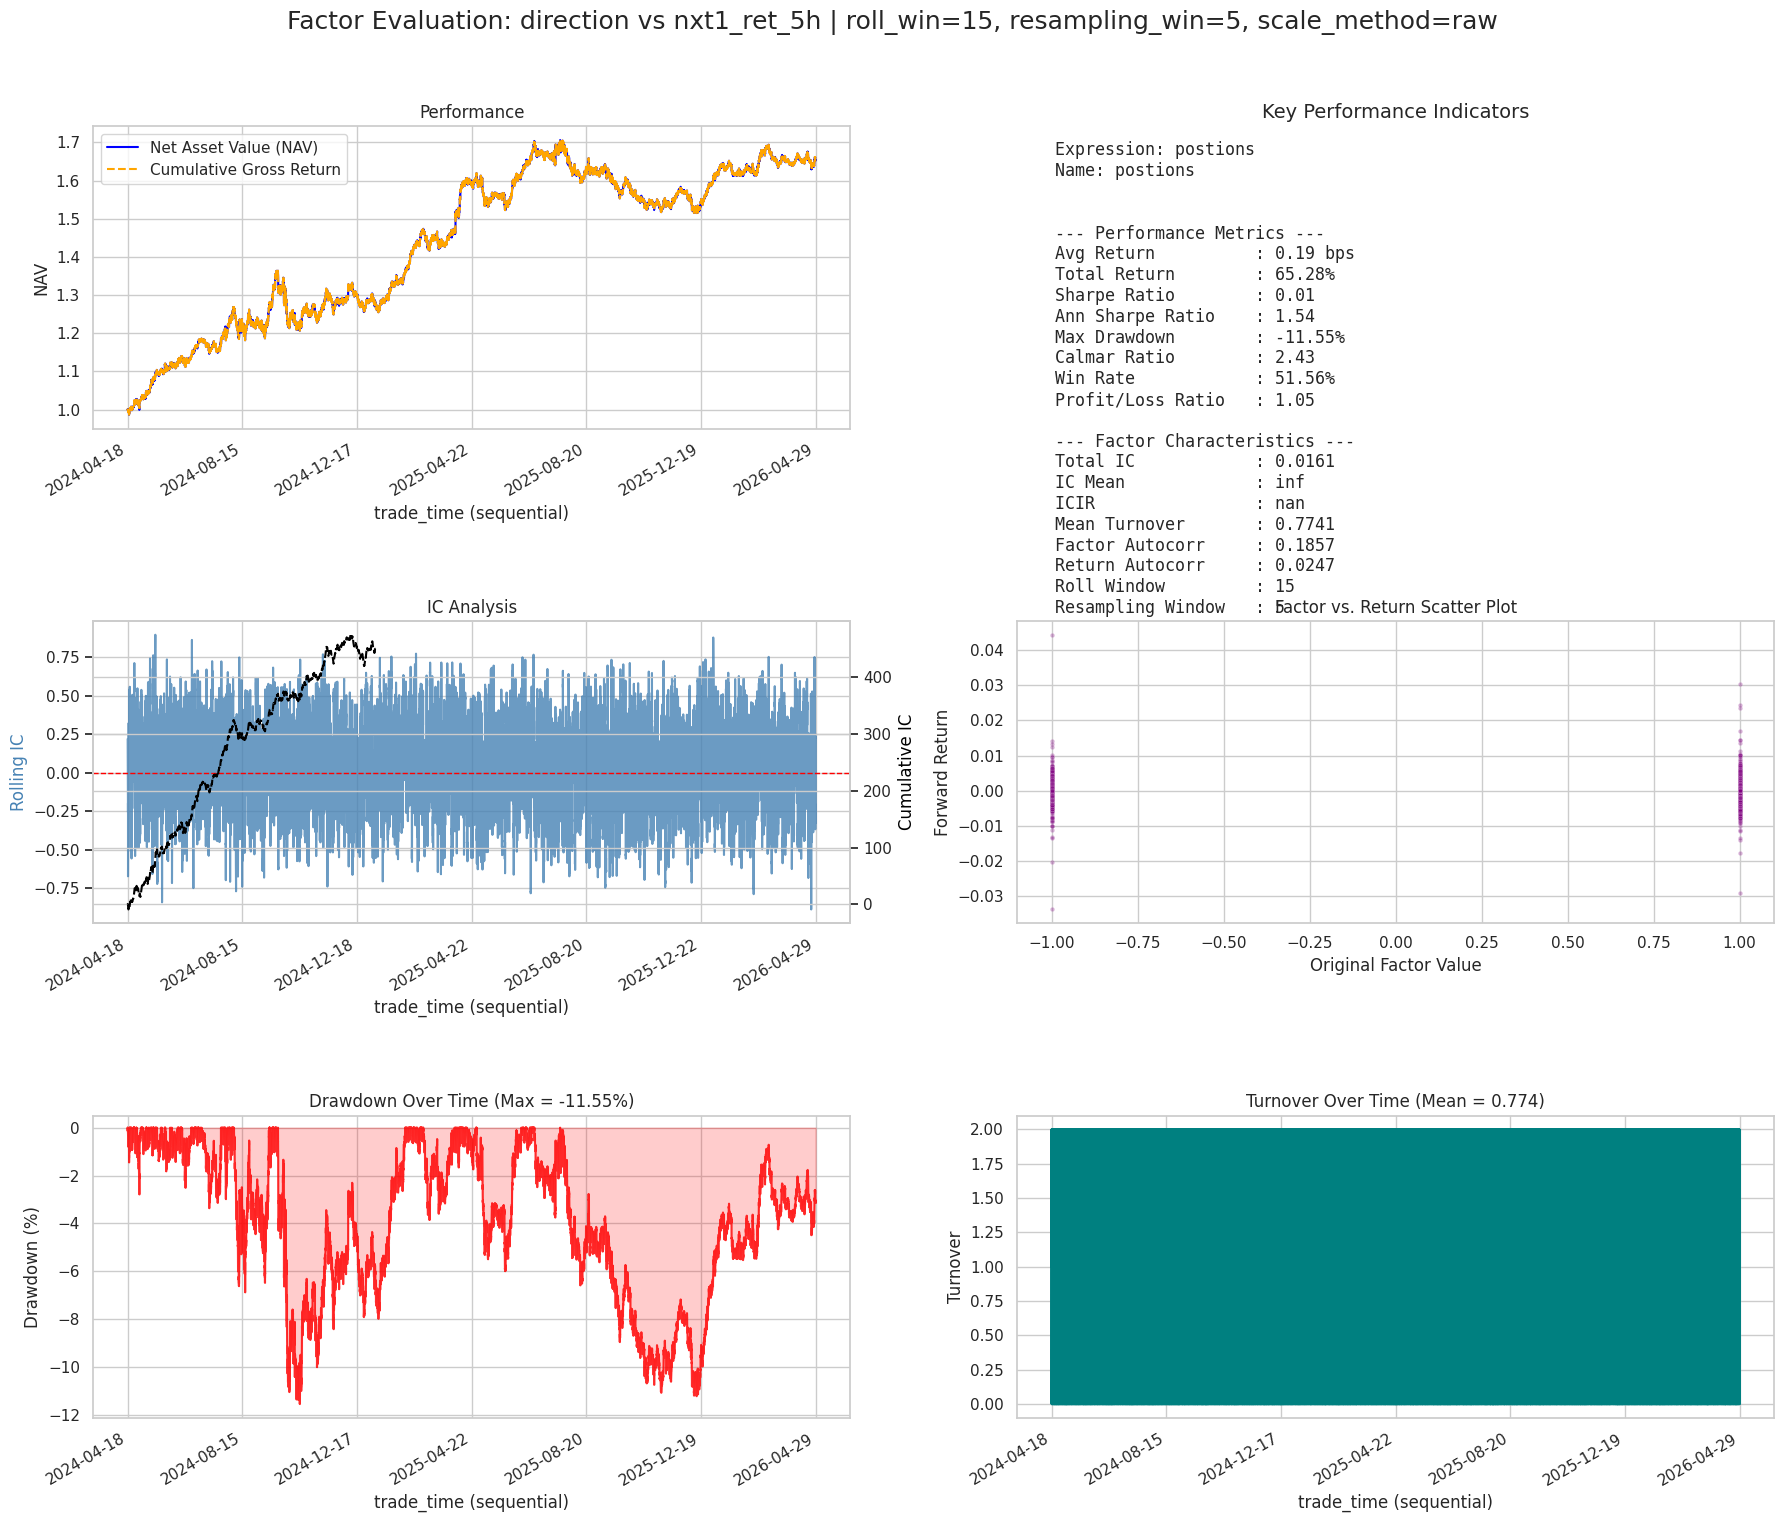

In [15]:
evaluate1 = FactorEvaluate1(factor_data=position_check,
                                   factor_name='direction',
                                   ret_name='nxt1_ret_5h',
                                   roll_win=15,
                                   fee=0.0,
                                   scale_method='raw',
                                   expression="postions",
                                   resampling_win=period,
                                   name="postions")
_ = evaluate1.run()
evaluate1.plot_results()

In [23]:
open_cmp1 = open_cmp.drop_duplicates(subset=['trade_time'])#[['trade_time','direction', 'nxt1_ret_5h']].tail()

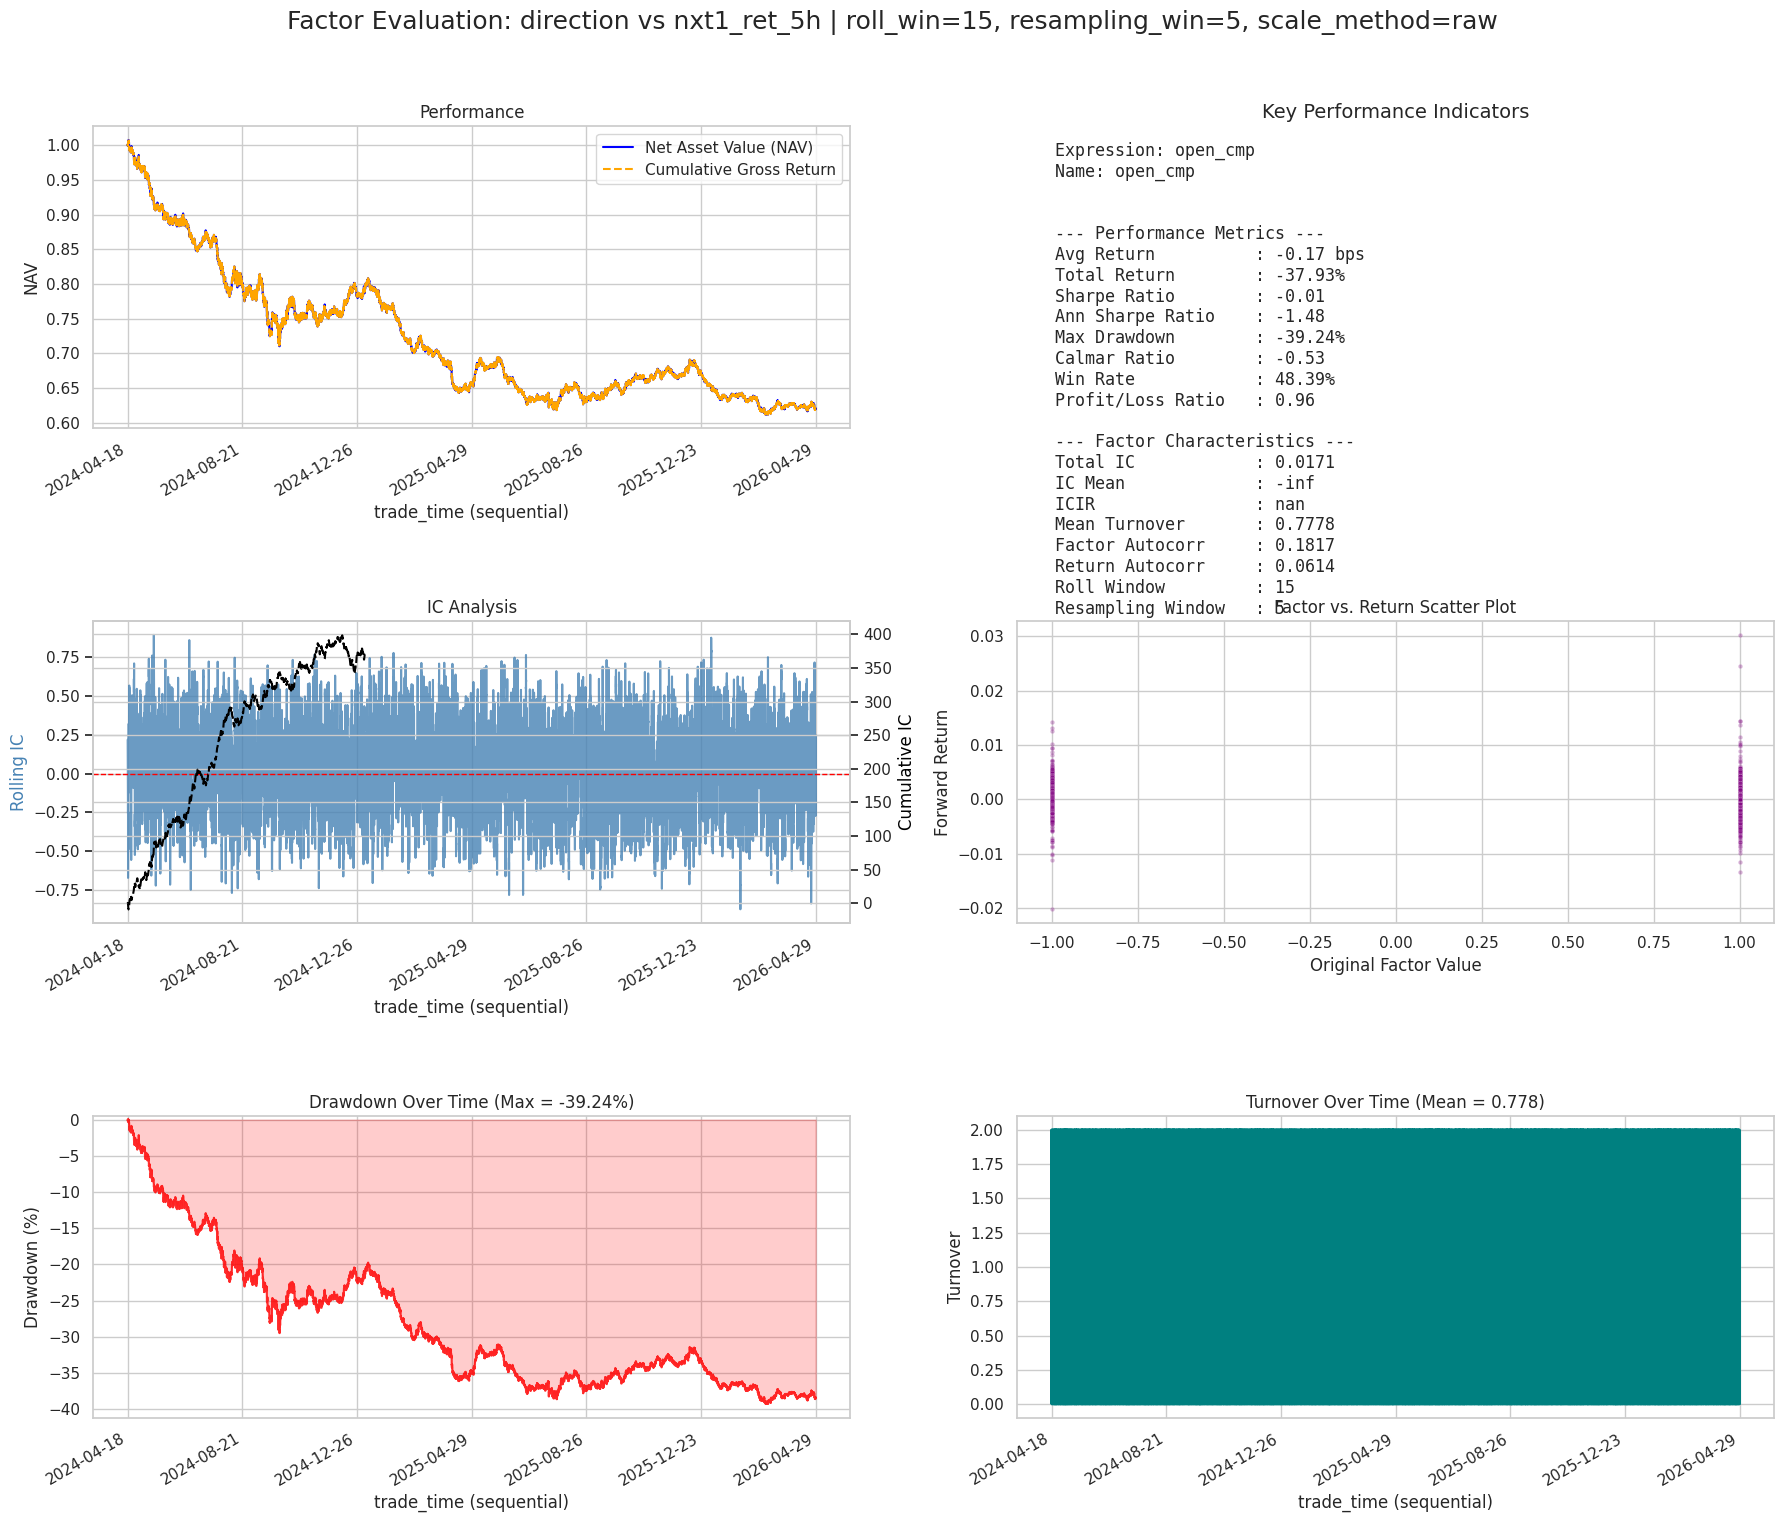

In [24]:
evaluate1 = FactorEvaluate1(factor_data=open_cmp1,
                                   factor_name='direction',
                                   ret_name='nxt1_ret_5h',
                                   roll_win=15,
                                   fee=0.0,
                                   scale_method='raw',
                                   expression="open_cmp",
                                   resampling_win=period,
                                   name="open_cmp")
sst2 = evaluate1.run()
evaluate1.plot_results()

In [27]:
open_cmp.shape

(129527, 10)